# Plot LCDM constraints from BAO measurements

In [1]:
import sys
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
from getdist import plots, loadMCSamples

%matplotlib inline

In [2]:
# figure out configuration for laptop vs NERSC
laptop=False
if laptop:
    cosmo_dir = '/Users/afont/Desktop/bao-cosmology'
else:
    cosmo_dir = '/global/cfs/cdirs/desi/users/font/bao-cosmology'
sys.path.insert(1, f'{cosmo_dir}/py/')
import plotting

In [3]:
# read chains from here
cosmo_path = Path(cosmo_dir)

### Plot single-tracer BAO forecasts from DESI

In [4]:
chains={}
for target in ['BGS', 'LRG', 'ELG', 'QSO', 'LYA']:
    chain_path = cosmo_path / 'runs/bao/lcdm/' / target
    chain = plotting.get_chain(chain_path, ignore_rows=0.2)
    chains[target] = chain

/global/cfs/cdirs/desi/users/font/bao-cosmology/runs/bao/lcdm/LYA/chain.1.txt
/global/cfs/cdirs/desi/users/font/bao-cosmology/runs/bao/lcdm/LYA/chain.2.txt
/global/cfs/cdirs/desi/users/font/bao-cosmology/runs/bao/lcdm/LYA/chain.3.txt
/global/cfs/cdirs/desi/users/font/bao-cosmology/runs/bao/lcdm/LYA/chain.4.txt
Removed 0.2 as burn in


In [5]:
include_all=True
if include_all:
    chain_path = cosmo_path / 'runs/bao/lcdm/desi-y5'
    chain = plotting.get_chain(chain_path, ignore_rows=0.2)
    chains['ALL'] = chain

(92.0, 105.0)

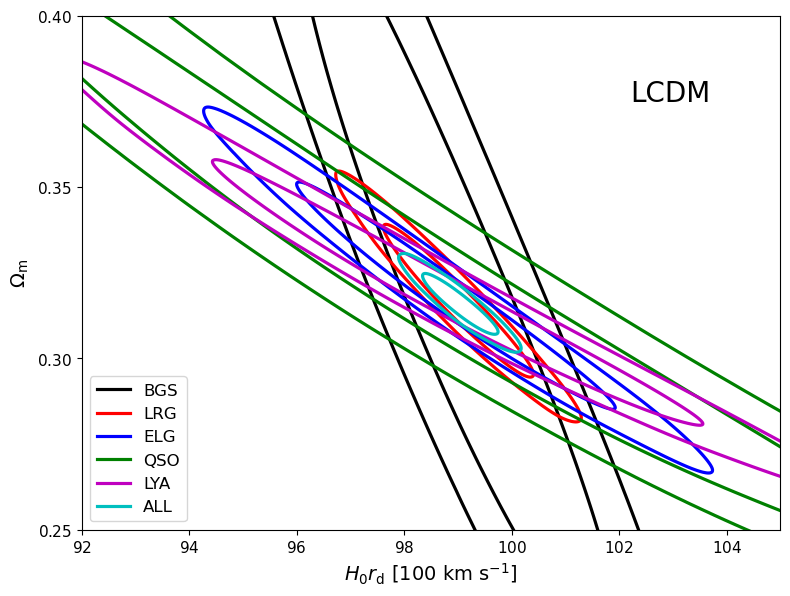

In [6]:
g, ax = plotting.plot_contours(chains, chain_labels=chains.keys(),  params=['hrdrag','omegam'])
g.add_text('LCDM', 0.90, 0.85, fontsize=20)
ax.set_xlabel(r'$H_0 r_\mathrm{d}$ [100 $\mathrm{km}$ $\mathrm{s}^{-1}$]')
ax.tick_params(axis='both', which='major', labelsize=g.settings.axes_fontsize)
ax.set_ylim(0.25, 0.4)
ax.set_xlim(92, 105)

### Plot DESI-5 BAO measurements for different models

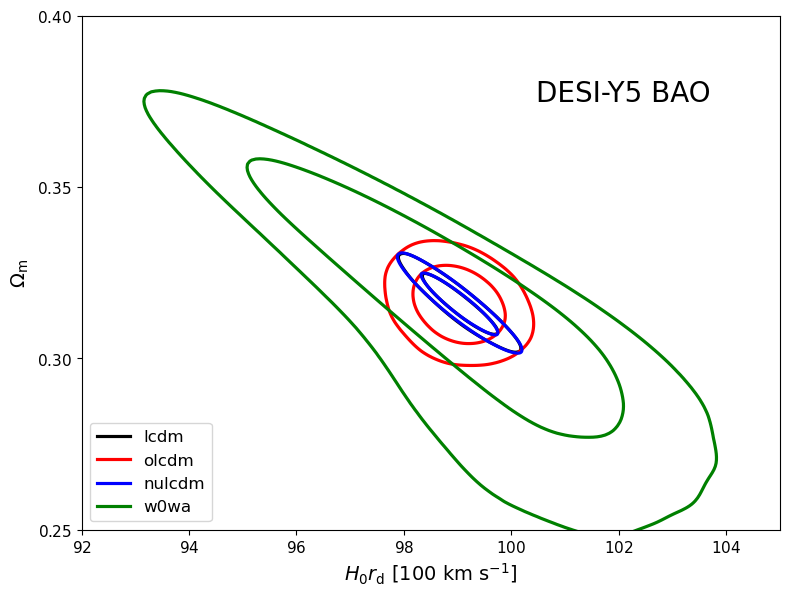

In [7]:
if not laptop:
    chains={}
    for model in ['lcdm', 'olcdm', 'nulcdm', 'w0wa']:
        chain_path = cosmo_path / 'runs/bao/' / model /'desi-y5'
        chain = plotting.get_chain(chain_path, ignore_rows=0.2)
        chains[model] = chain
    g, ax = plotting.plot_contours(chains, chain_labels=chains.keys(),  params=['hrdrag','omegam'])
    g.add_text('DESI-Y5 BAO', 0.90, 0.85, fontsize=20)
    ax.set_xlabel(r'$H_0 r_\mathrm{d}$ [100 $\mathrm{km}$ $\mathrm{s}^{-1}$]')
    ax.tick_params(axis='both', which='major', labelsize=g.settings.axes_fontsize)
    ax.set_ylim(0.25, 0.4)
    ax.set_xlim(92, 105)

### Plot toy BAO measurements

In [8]:
chains={}
mock_labels = ['mock_z0.001_bao', 'mock_z10.0_ap', 'mock_cmb_bao']
for mock_label in mock_labels:
    chain_path = cosmo_path / 'runs/bao/lcdm/' / mock_label
    chain = plotting.get_chain(chain_path, ignore_rows=0.2)
    chains[mock_label] = chain

(95.0, 102.0)

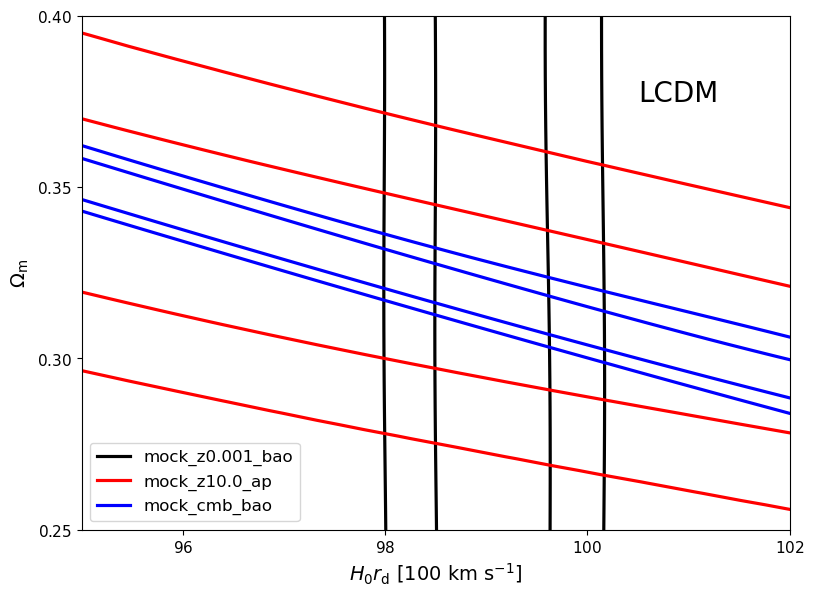

In [10]:
g, ax = plotting.plot_contours(chains, chain_labels=chains.keys(),  params=['hrdrag','omegam'])
g.add_text('LCDM', 0.90, 0.85, fontsize=20)
ax.set_xlabel(r'$H_0 r_\mathrm{d}$ [100 $\mathrm{km}$ $\mathrm{s}^{-1}$]')
ax.tick_params(axis='both', which='major', labelsize=g.settings.axes_fontsize)
ax.set_ylim(0.25, 0.4)
ax.set_xlim(95, 102)